In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from WBUtiles.WBClean import clean_wb_wide
from WBUtiles.WBSummary import summary_wb, plot_missing_heatmap

sns.set_theme(
    style="whitegrid",     # clean academic look
    context="paper",       # scales text for papers
    font_scale=1.1
)

# Data Cleaning

In [2]:
capital_accum = pd.read_csv('../data/Zambia_CapitalAccumulation/capital_accum.csv')

In [3]:
cap_accum_clean, cap_accum_lookup = clean_wb_wide(capital_accum, drop_top_rows=0)

In [4]:
latex = cap_accum_lookup.to_latex(
    index=False,
    escape=True,
    column_format='lp{10cm}',
    caption='World Bank indicators used in Capital Accumulation Analysis',
    label='tab:ca_indicator_list'
)

print(latex)

\begin{table}
\caption{World Bank indicators used in Capital Accumulation Analysis}
\label{tab:ca_indicator_list}
\begin{tabular}{lp{10cm}}
\toprule
Series Code & Series Name \\
\midrule
SP.URB.TOTL & Urban population \\
SP.URB.TOTL.IN.ZS & Urban population (\% of total population) \\
SP.URB.GROW & Urban population growth (annual \%) \\
DT.DOD.DECT.GN.ZS & External debt stocks (\% of GNI) \\
DT.DOD.DLXF.CD & External debt stocks, long-term (DOD, current US\$) \\
NV.AGR.TOTL.ZS & Agriculture, forestry, and fishing, value added (\% of GDP) \\
BN.CAB.XOKA.GD.ZS & Current account balance (\% of GDP) \\
NY.GDP.MKTP.CD & GDP (current US\$) \\
NE.GDI.TOTL.ZS & Gross capital formation (\% of GDP) \\
NY.GDS.TOTL.ZS & Gross domestic savings (\% of GDP) \\
NV.IND.TOTL.ZS & Industry (including construction), value added (\% of GDP) \\
NV.SRV.TOTL.ZS & Services, value added (\% of GDP) \\
\bottomrule
\end{tabular}
\end{table}



# Check data availability by series and year

In [5]:
cap_accum_summary = summary_wb(cap_accum_clean, cap_accum_lookup)
cap_accum_summary

,Series Code,Series Name,missing_pct,n_obs,first_year,last_year
0,SP.URB.TOTL,Urban population,0.000000,65,1960,2024
1,SP.URB.TOTL.IN.ZS,Urban population (% of total population),0.000000,65,1960,2024
2,SP.URB.GROW,Urban population growth (annual %),1.538462,64,1961,2024
3,DT.DOD.DECT.GN.ZS,External debt stocks (% of GNI),15.384615,55,1970,2024
4,DT.DOD.DLXF.CD,"External debt stocks, long-term (DOD, current ...",15.384615,55,1970,2024
5,NV.AGR.TOTL.ZS,"Agriculture, forestry, and fishing, value adde...",0.000000,65,1960,2024
6,BN.CAB.XOKA.GD.ZS,Current account balance (% of GDP),35.384615,42,1978,2024
7,NY.GDP.MKTP.CD,GDP (current US$),0.000000,65,1960,2024
8,NE.GDI.TOTL.ZS,Gross capital formation (% of GDP),76.923077,15,2010,2024
9,NY.GDS.TOTL.ZS,Gross domestic savings (% of GDP),76.923077,15,2010,2024


In [18]:
summary_latex = cap_accum_summary.drop(columns=['Series Name']).copy()

summary_latex['missing_pct'] = summary_latex['missing_pct'].round(1)

summary_latex = summary_latex.rename(columns={
    'Series Code': 'Series Code',
    'Series Name': 'Series Name',
    'missing_pct': 'Missing (\\%)',
    'n_obs': 'Obs.',
    'first_year': 'First year',
    'last_year': 'Last year'
})

print(
    summary_latex.to_latex(
        index=False,
        escape=True,
        float_format="%.2f",
        caption='Data availability of Capital Accumulation (Zambia)',
        label='tab:ca_data_availability',
    )
)

\begin{table}
\caption{Data availability of Capital Accumulation (Zambia)}
\label{tab:ca_data_availability}
\begin{tabular}{lrrrr}
\toprule
Series Code & Missing (\textbackslash \%) & Obs. & First year & Last year \\
\midrule
SP.URB.TOTL & 0.00 & 65 & 1960 & 2024 \\
SP.URB.TOTL.IN.ZS & 0.00 & 65 & 1960 & 2024 \\
SP.URB.GROW & 1.50 & 64 & 1961 & 2024 \\
DT.DOD.DECT.GN.ZS & 15.40 & 55 & 1970 & 2024 \\
DT.DOD.DLXF.CD & 15.40 & 55 & 1970 & 2024 \\
NV.AGR.TOTL.ZS & 0.00 & 65 & 1960 & 2024 \\
BN.CAB.XOKA.GD.ZS & 35.40 & 42 & 1978 & 2024 \\
NY.GDP.MKTP.CD & 0.00 & 65 & 1960 & 2024 \\
NE.GDI.TOTL.ZS & 76.90 & 15 & 2010 & 2024 \\
NY.GDS.TOTL.ZS & 76.90 & 15 & 2010 & 2024 \\
NV.IND.TOTL.ZS & 0.00 & 65 & 1960 & 2024 \\
NV.SRV.TOTL.ZS & 35.40 & 42 & 1983 & 2024 \\
\bottomrule
\end{tabular}
\end{table}



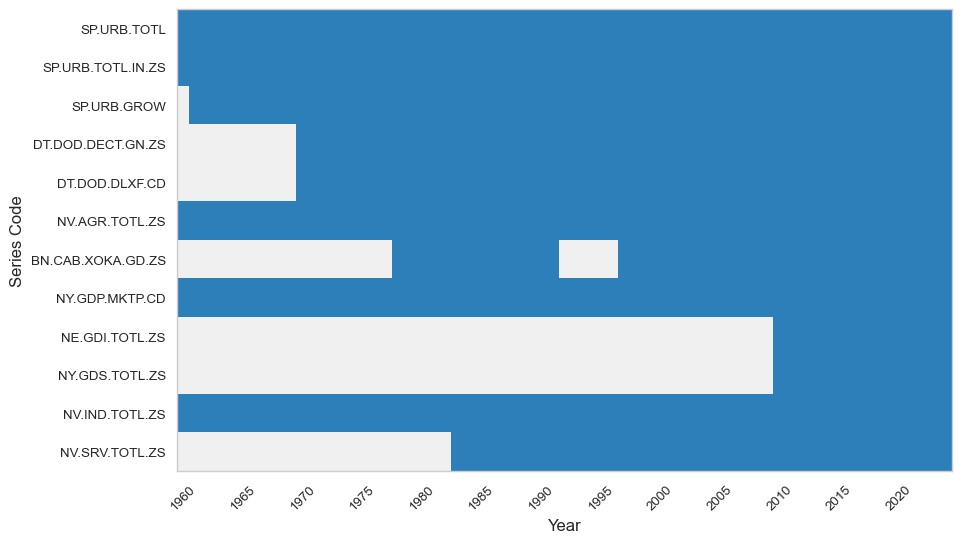

In [19]:
availability, fig, ax = plot_missing_heatmap(
    cap_accum_clean,
    lookup=cap_accum_lookup
)

fig.savefig(
    "../figures/capital_accum/data_availability_heatmap.pdf",
    format="pdf",
    bbox_inches="tight"
)

# Data Visualization

In [20]:
cap_accum_lookup

,Series Code,Series Name
0,SP.URB.TOTL,Urban population
1,SP.URB.TOTL.IN.ZS,Urban population (% of total population)
2,SP.URB.GROW,Urban population growth (annual %)
3,DT.DOD.DECT.GN.ZS,External debt stocks (% of GNI)
4,DT.DOD.DLXF.CD,"External debt stocks, long-term (DOD, current ..."
5,NV.AGR.TOTL.ZS,"Agriculture, forestry, and fishing, value adde..."
6,BN.CAB.XOKA.GD.ZS,Current account balance (% of GDP)
7,NY.GDP.MKTP.CD,GDP (current US$)
8,NE.GDI.TOTL.ZS,Gross capital formation (% of GDP)
9,NY.GDS.TOTL.ZS,Gross domestic savings (% of GDP)


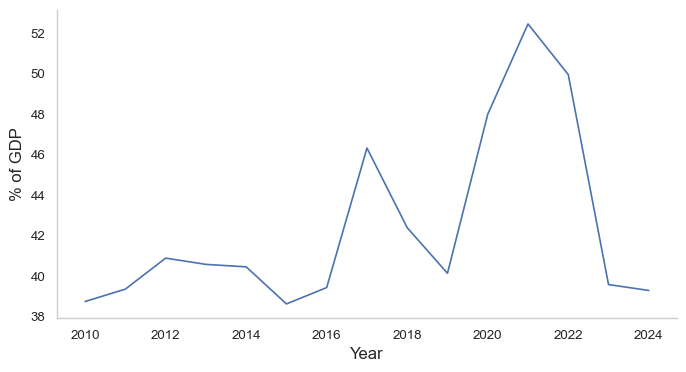

In [21]:
# gross domestic savings rate
df = cap_accum_clean.set_index('Year')
fig, ax = plt.subplots(figsize=(8,4))

ax.plot(df.index, df['NY.GDS.TOTL.ZS'])
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("% of GDP", fontsize=12)

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(
    "../figures/capital_accum/GDS_total.pdf",
    format="pdf",
    bbox_inches="tight"
)

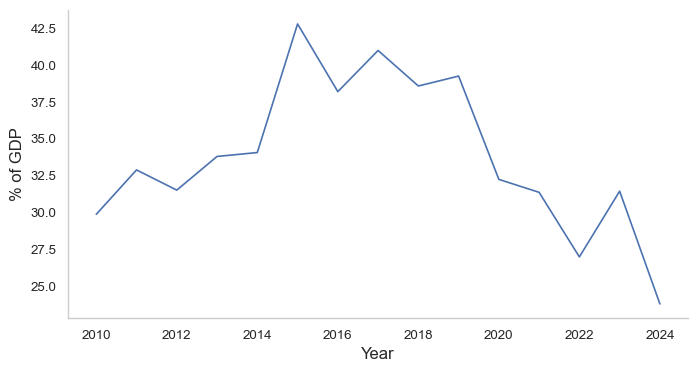

In [22]:
# capital stock as percent of GDP (Gross capital formation)
df = cap_accum_clean.set_index('Year')
fig, ax = plt.subplots(figsize=(8,4))

ax.plot(df.index, df['NE.GDI.TOTL.ZS'])
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("% of GDP", fontsize=12)

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(
    "../figures/capital_accum/GCF_total.pdf",
    format="pdf",
    bbox_inches="tight"
)

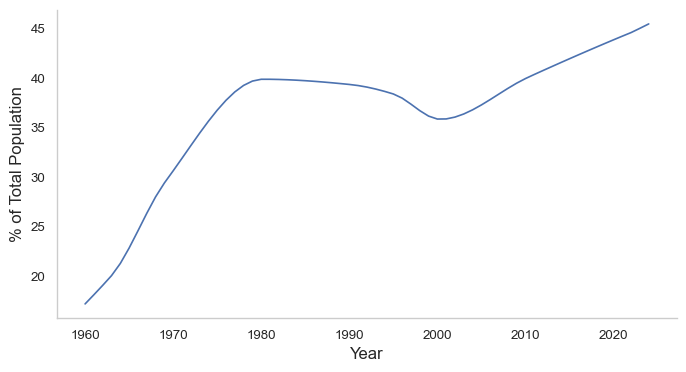

In [23]:
# urban population as percent of total population
df = cap_accum_clean.set_index('Year')
fig, ax = plt.subplots(figsize=(8,4))

ax.plot(df.index, df['SP.URB.TOTL.IN.ZS'])
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("% of Total Population", fontsize=12)

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(
    "../figures/capital_accum/urban_pop.pdf",
    format="pdf",
    bbox_inches="tight"
)

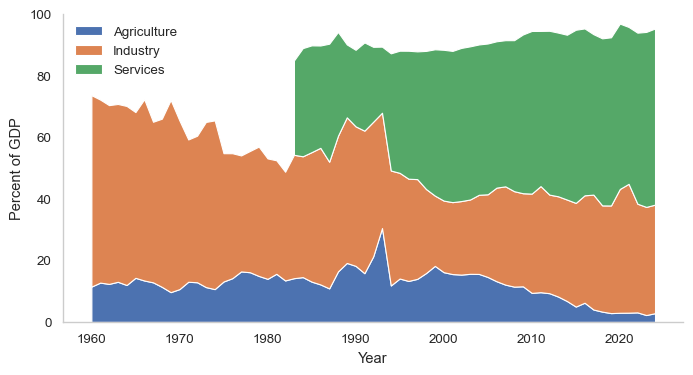

In [24]:
# structure of production: agriculture, industry, services
df = cap_accum_clean.set_index('Year')

sectors = df[['NV.AGR.TOTL.ZS',
              'NV.IND.TOTL.ZS',
              'NV.SRV.TOTL.ZS']]

fig, ax = plt.subplots(figsize=(8,4))

ax.stackplot(
    sectors.index,
    sectors['NV.AGR.TOTL.ZS'],
    sectors['NV.IND.TOTL.ZS'],
    sectors['NV.SRV.TOTL.ZS'],
    labels=['Agriculture', 'Industry', 'Services']
)

ax.set_ylabel('Percent of GDP')
ax.set_xlabel('Year')
ax.legend(frameon=False)

ax.set_ylim(0,100)

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(
    "../figures/capital_accum/Production_Struction.pdf",
    format="pdf",
    bbox_inches="tight"
)

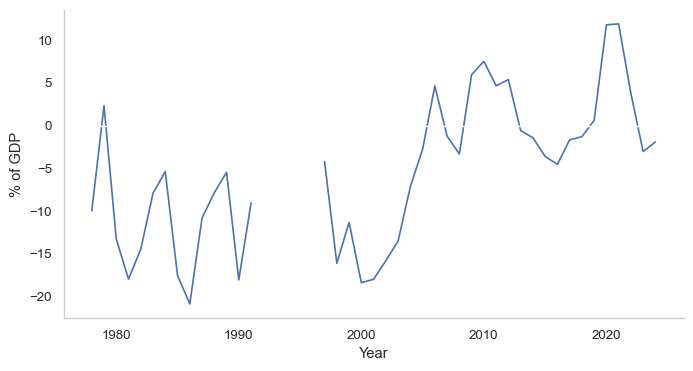

In [25]:
# average of current account surplus (or deficit)
df = cap_accum_clean.set_index('Year')
fig, ax = plt.subplots(figsize=(8,4))

ax.plot(df.index, df['BN.CAB.XOKA.GD.ZS'])
ax.axhline(0, linewidth=1)

ax.set_ylabel('% of GDP')
ax.set_xlabel('Year')

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(
    "../figures/capital_accum/CAS_annual.pdf",
    format="pdf",
    bbox_inches="tight"
)

In [26]:
# keep annual growth
df_growth = cap_accum_clean[['Year', 'BN.CAB.XOKA.GD.ZS']].dropna()

# define decade
df_growth['decade'] = (df_growth['Year'] // 10) * 10

# compute average annual growth per decade
decadal_avg = (
    df_growth.groupby('decade')['BN.CAB.XOKA.GD.ZS']
    .mean()
    .reset_index()
)

# keep only full decades if you prefer (optional)
# decadal_avg = decadal_avg[decadal_avg['decade'] >= 1980]

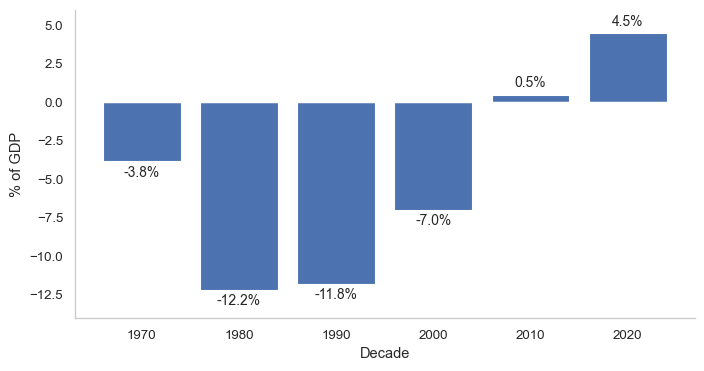

In [27]:
fig, ax = plt.subplots(figsize=(8,4))

bars = ax.bar(
    decadal_avg['decade'].astype(str),
    decadal_avg['BN.CAB.XOKA.GD.ZS']
)

ax.axhline(0, linewidth=1)
ax.set_xlabel('Decade')
ax.set_ylabel('% of GDP')

ax.set_ylim(-14, 6)

# Add percentage labels
for bar in bars:
    height = bar.get_height()

    if height >= 0:
        y = height + 0.3
        va = 'bottom'
    else:
        y = height - 0.3
        va = 'top'

    ax.text(
        bar.get_x() + bar.get_width()/2,
        y,
        f'{height:.1f}%',
        ha='center',
        va=va,
        fontsize=10
    )

# Clean style (journal ready)
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(
    "../figures/capital_accum/CAS_decade.pdf",
    format="pdf",
    bbox_inches="tight"
)

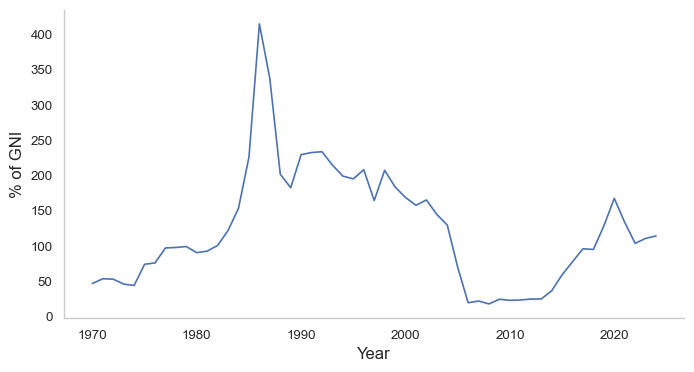

In [28]:
# total external debt
df = cap_accum_clean.set_index('Year')
fig, ax = plt.subplots(figsize=(8,4))

ax.plot(df.index, df['DT.DOD.DECT.GN.ZS'])
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("% of GNI", fontsize=12)

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(
    "../figures/capital_accum/External_Debt.pdf",
    format="pdf",
    bbox_inches="tight"
)

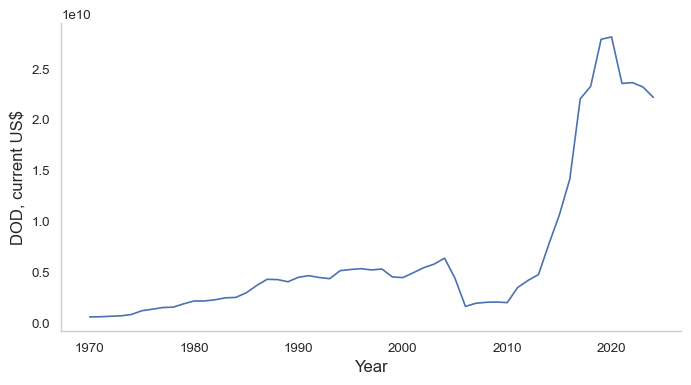

In [29]:
# total external debt
df = cap_accum_clean.set_index('Year')
fig, ax = plt.subplots(figsize=(8,4))

ax.plot(df.index, df['DT.DOD.DLXF.CD'])
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("DOD, current US$", fontsize=12)

ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

fig.savefig(
    "../figures/capital_accum/External_Debt_DDD.pdf",
    format="pdf",
    bbox_inches="tight"
)